## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 6: Clustering ``GaussianMixture()``**

Andrés C. Medina Sanhueza  
Senior Data Scientist Engineer  
anmedinas@gmail.com



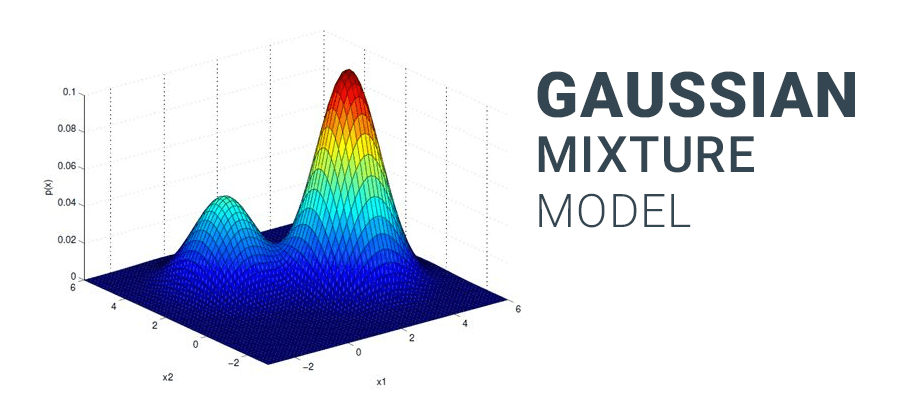

In [ ]:
from IPython.display import Image
Image('../figs/gmm.png')

### **Gaussian Mixture Model (GMM)**

----
**Generación de Simulaciones**

Dada una variable aleatoria $X$, decimos que la frecuencia de sus observaciones puede aproximarse satisfactoriamente a una normal $\mathcal{N}(\mu,\sigma^2)$, donde la función de densidad de probabilidad tiene el siguiente aspecto.

\begin{equation*}
f(x) = \frac{1}{\sqrt{2\pi\sigma}}\exp{\left( -\frac{(x-\mu)^2}{2\sigma^2}\right)}\quad  \mu,x\in\mathbb{R}\quad\sigma > 0
\end{equation*}

Donde, los parámetros de esta distribución, son la media o parámetro de localización $\mu$ y la desviación típica o parámetro de escala $\sigma$. 

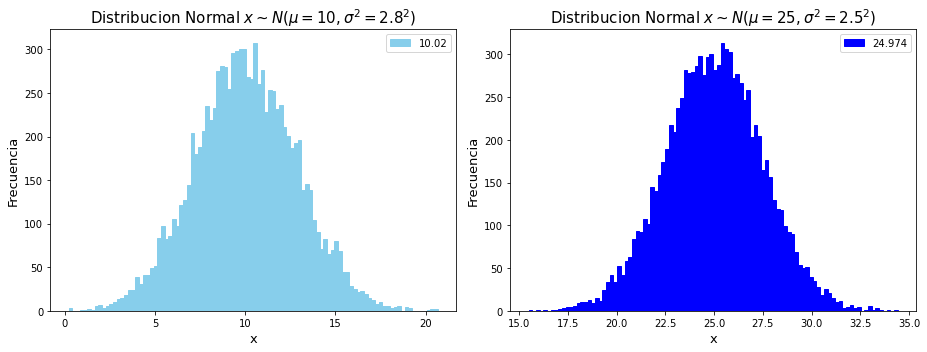

In [2]:
from scipy.stats import norm
from matplotlib import pyplot as plt
import seaborn as sns 
import numpy as np

# Semilla aleatoria
np.random.seed(20210910)

# Generacion de datos normales
data_normal_01 = norm.rvs(size=10000, loc=10, scale=2.8)
data_normal_02 = norm.rvs(size=10000, loc=25, scale=2.5)

# Visualizacion distribucion
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

# Histograma 01
ax1.hist(data_normal_01, bins = 100, label=np.mean(data_normal_01).round(3), color = "skyblue", ec="skyblue")
ax1.set_xlabel("x", fontsize = 13)
ax1.set_ylabel("Frecuencia", fontsize = 13)
ax1.set_title("Distribucion Normal $x\sim N(\mu=10, \sigma^2=2.8^2)$", fontsize=15)
ax1.legend(loc=1)

# Histograma 02 
ax2.hist(data_normal_02, bins = 100, label=np.mean(data_normal_02).round(3), color = "blue", ec="blue")
ax2.set_xlabel("x", fontsize = 13)
ax2.set_ylabel("Frecuencia", fontsize = 13)
ax2.set_title("Distribucion Normal $x\sim N(\mu=25, \sigma^2=2.5^2)$", fontsize=15)
ax2.legend(loc=1)
plt.tight_layout()

----
**Máxima Verosimilitud**

Sea el Modelo lineal gausiano


\begin{equation*}
Y = X\beta + \epsilon
\end{equation*}


Luego, la media y varianza quedan caracterizadas como:


\begin{align*}
\mathbb{E}(Y|X) &=& \mathbb{E}(X\beta + \epsilon|X) = \mathbb{E}(X\beta|X)=X\beta \\
\mathbb{V}(Y|X) &=& \mathbb{V}(X\beta + \epsilon|X) = \mathbb{V}(\epsilon|X)=\sigma^2 I
\end{align*}


El proceso generador de datos y la distribución de los estimadores vienen dados por:

\begin{align*}
Y|X &\sim& \mathcal{N}(X\beta,\sigma^2 I) \\
\hat{\beta}|X &\sim& \mathcal{N}(\beta,\sigma^2(X^{T}X)^{-1})
\end{align*}

Implemente computacionalmente la log-verosimilitud del modelo de regresión lineal y corrobore los estimadores con los obtenidos mediante statsmodels.

Recordar que el MLE de un modelo de regresión lineal, es de la siguiente forma:


\begin{equation*}
\mathcal{l}(\beta,\sigma^2) = 
\sum_{i=1}^{n}\log\left(\frac{1}{\sqrt{2\pi\sigma^2}}\exp\left[-\frac{(y_{i}-x_{i}^{\top}\beta)^2}{2\sigma^2}\right]\right)
\end{equation*}


In [3]:
from scipy.optimize import minimize
from scipy.stats import norm
import scipy.stats as stats
import numpy as np
import random
import matplotlib.pyplot as plt

# Semilla aleatoria
np.random.seed(20210730)

# Parametros de inicializacion
N = 100
beta_0 = 3
beta_1 = 8

# Generacion de muestras aleatorias
X = np.random.normal(loc = 10, scale = 2, size = N)
e = np.random.normal(loc = 0, scale = 2, size = len(X))
Y = beta_0 + beta_1 * X + e

In [4]:
def log_lik(par_vec, y, x):
    # Si la desviacion estandar es negativa, devuelve un numero grande
    if par_vec[2] < 0:
        return(1e8)
    # La funcion de verosimilitud se define como:
    lik = norm.pdf(y, loc = par_vec[0] + par_vec[1] * x, scale = par_vec[2])
    # Esto es similar a calcular la verosimilitud de  Y - XB
    # res = y - par_vec[0] - par_vec[1] * x
    # lik = norm.pdf(res, loc = 0, sd = par_vec[2])
    
    # Si todos los logaritmos son ceros, retorna un valor grande
    if all(v == 0 for v in lik):
        return(1e8)
    # Logaritmo de cero = -Inf
    return(-sum(np.log(lik[np.nonzero(lik)])))

In [5]:
import scipy.optimize as optimize
opt_res = minimize(fun = log_lik, x0 = [0, 0, 10], args = (Y, X))
print(opt_res)

      fun: 213.90749357634093
 hess_inv: array([[ 0.01160638, -0.00096676,  0.00167989],
       [-0.00096676,  0.00052478,  0.00048763],
       [ 0.00167989,  0.00048763,  0.03963194]])
      jac: array([ 0.00000000e+00, -7.62939453e-06, -3.81469727e-06])
  message: 'Optimization terminated successfully.'
     nfev: 148
      nit: 23
     njev: 37
   status: 0
  success: True
        x: array([4.45134419, 7.87592208, 2.0547133 ])


In [6]:
# Verificacion de la estimacion por Maxima Verosimilitud
import statsmodels.api as sms
import statsmodels.formula.api as smf

X = sms.add_constant(X, prepend=True)
modelo = sms.OLS(Y,X)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     5509.
Date:                Thu, 23 Sep 2021   Prob (F-statistic):           6.20e-88
Time:                        19:47:11   Log-Likelihood:                -213.91
No. Observations:                 100   AIC:                             431.8
Df Residuals:                      98   BIC:                             437.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4513      1.072      4.153      0.0

----
**Visualización Distribuciones Normales Multivariantes**

In [7]:
from scipy.stats import multivariate_normal

In [8]:
def ejemplos_distribuciones_normales():
    x, y = np.mgrid[-1:1:0.01, -1:1:0.01]
    posicion = np.dstack((x,y))
    
    rv1 = multivariate_normal(mean=[0, 0], cov=[[0.1, 0],[0, 0.1]])
    rv2 = multivariate_normal(mean=[0, 0], cov=[[1, 0],[0, 1]])
    rv3 = multivariate_normal(mean=[0.5, -1], cov=[[1, 0],[0, 1]])
    
    rv4 = multivariate_normal(mean=[0, 0], cov=[[1, 0],[0, 1]])
    rv5 = multivariate_normal(mean=[0, 0], cov=[[1, 0.5],[0.5, 1]])
    rv6 = multivariate_normal(mean=[0, 0], cov=[[1, 0.9],[0.9, 1]])
       
    rv7 = multivariate_normal(mean=[0, 0], cov=[[1, 0],[0, 1]])
    rv8 = multivariate_normal(mean=[0, 0], cov=[[1, -0.5],[-0.5, 1]])
    rv9 = multivariate_normal(mean=[0, 0], cov=[[1, -0.9],[-0.9, 1]])    
        
    fig, ([ax1,ax2,ax3],[ax4,ax5,ax6],[ax7,ax8,ax9]) = plt.subplots(3, 3, figsize=(10,10))
    
    # Primera Fila
    ax1.contourf(x, y, rv1.pdf(posicion), cmap='jet')
    ax1.set_title('$\mu=0$, $\Sigma=[0.1, 0]$', fontsize=15)
    ax2.contourf(x, y, rv2.pdf(posicion), cmap='jet')
    ax2.set_title('$\mu=0$, $\Sigma=[1, 0]$', fontsize=15)
    ax3.contourf(x, y, rv3.pdf(posicion), cmap='jet')
    ax3.set_title('$\mu=[0.5, -1]$, $\Sigma=[1, 0]$', fontsize=15)
    
    # Segunda Fila 
    ax4.contourf(x, y, rv4.pdf(posicion), cmap='jet')
    ax4.set_title('$\mu=0$, $\Sigma=[1, 0]$', fontsize=15)
    ax5.contourf(x, y, rv5.pdf(posicion), cmap='jet')
    ax5.set_title('$\mu=0$, $\Sigma=[1, 0.5]$', fontsize=15)
    ax6.contourf(x, y, rv6.pdf(posicion), cmap='jet')
    ax6.set_title('$\mu=0$, $\Sigma=[1, 0.9]$', fontsize=15)
    
    # Tercera Fila 
    ax7.contourf(x, y, rv7.pdf(posicion), cmap='jet')
    ax7.set_title('$\mu=0$, $\Sigma=[1, 0]$', fontsize=15)
    ax8.contourf(x, y, rv8.pdf(posicion), cmap='jet')
    ax8.set_title('$\mu=0$, $\Sigma=[1, -0.5]$', fontsize=15)
    ax9.contourf(x, y, rv9.pdf(posicion), cmap='jet')
    ax9.set_title('$\mu=0$, $\Sigma=[1, -0.9]$', fontsize=15)
    
    plt.tight_layout()

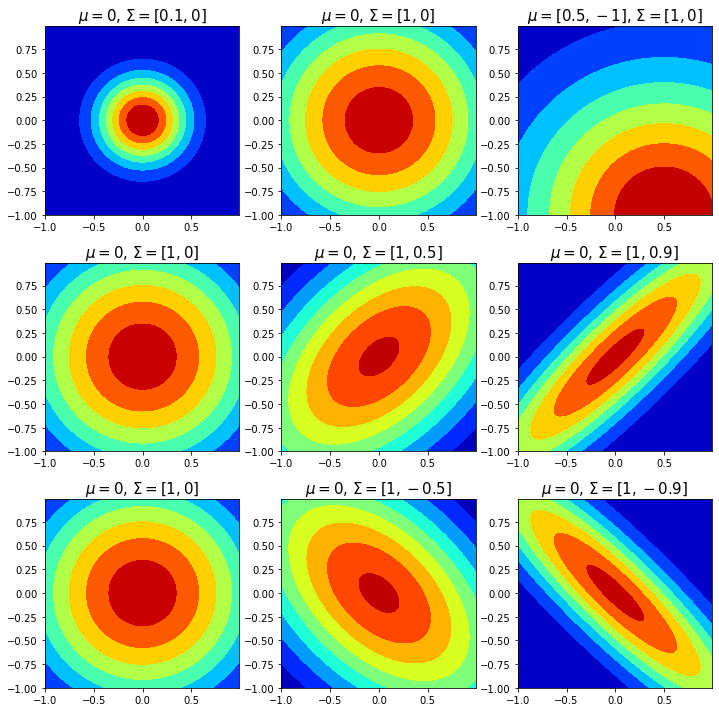

In [9]:
ejemplos_distribuciones_normales()

In [10]:
def crea_mixturas_gausianas(pis, mus, Sigmas, N=5000, rseed=None):
    
    if rseed is not None:
        np.random.seed(rseed)
    
    puntos = []
    etiquetas = []
    for k in range(len(pis)):
        Nc = int(pis[k]*N) # Parametro concentracion (pi grande, mas importante)
        if len(mus[k]) > 1 :
            # Modelo Generativo 
            x = np.random_multivariate_normal(mus[k], Sigmas[k], Nc)
        else : 
            x = mus[k] + np.sqrt(Sigmas[k])*np.random.randn(Nc)
        puntos.append(x)
        etiquetas.append([k]*Nc)
    return np.concatenate(puntos), np.concatenate(etiquetas)

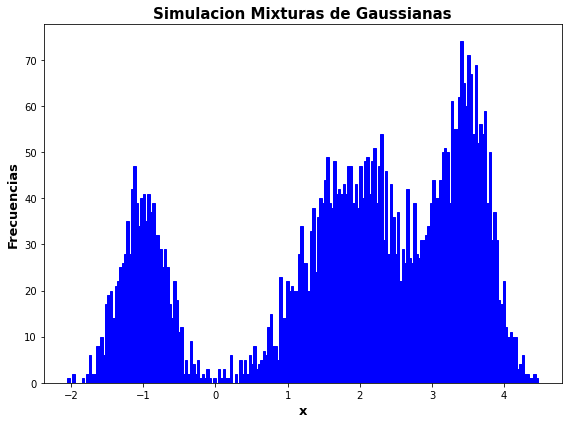

In [11]:
data, labels = crea_mixturas_gausianas(pis = [0.2, 0.5, 0.3],
                                       mus = [[-1], [2], [3.5]],
                                       Sigmas = [0.1, 0.5, 0.1])

fig, ax = plt.subplots(1, figsize=(8,6), tight_layout=True)
ax.hist(data, bins=200, color = "blue", ec="blue")
ax.set_title("Simulacion Mixturas de Gaussianas", fontsize=15,fontweight='bold')
ax.set_xlabel("x", fontsize=13, fontweight='bold')
ax.set_ylabel("Frecuencias", fontsize=13, fontweight='bold')
plt.show()

----
Para el algoritmo de GMM, se utiliza la clase `sklearn.mixture.GaussianMixture`.

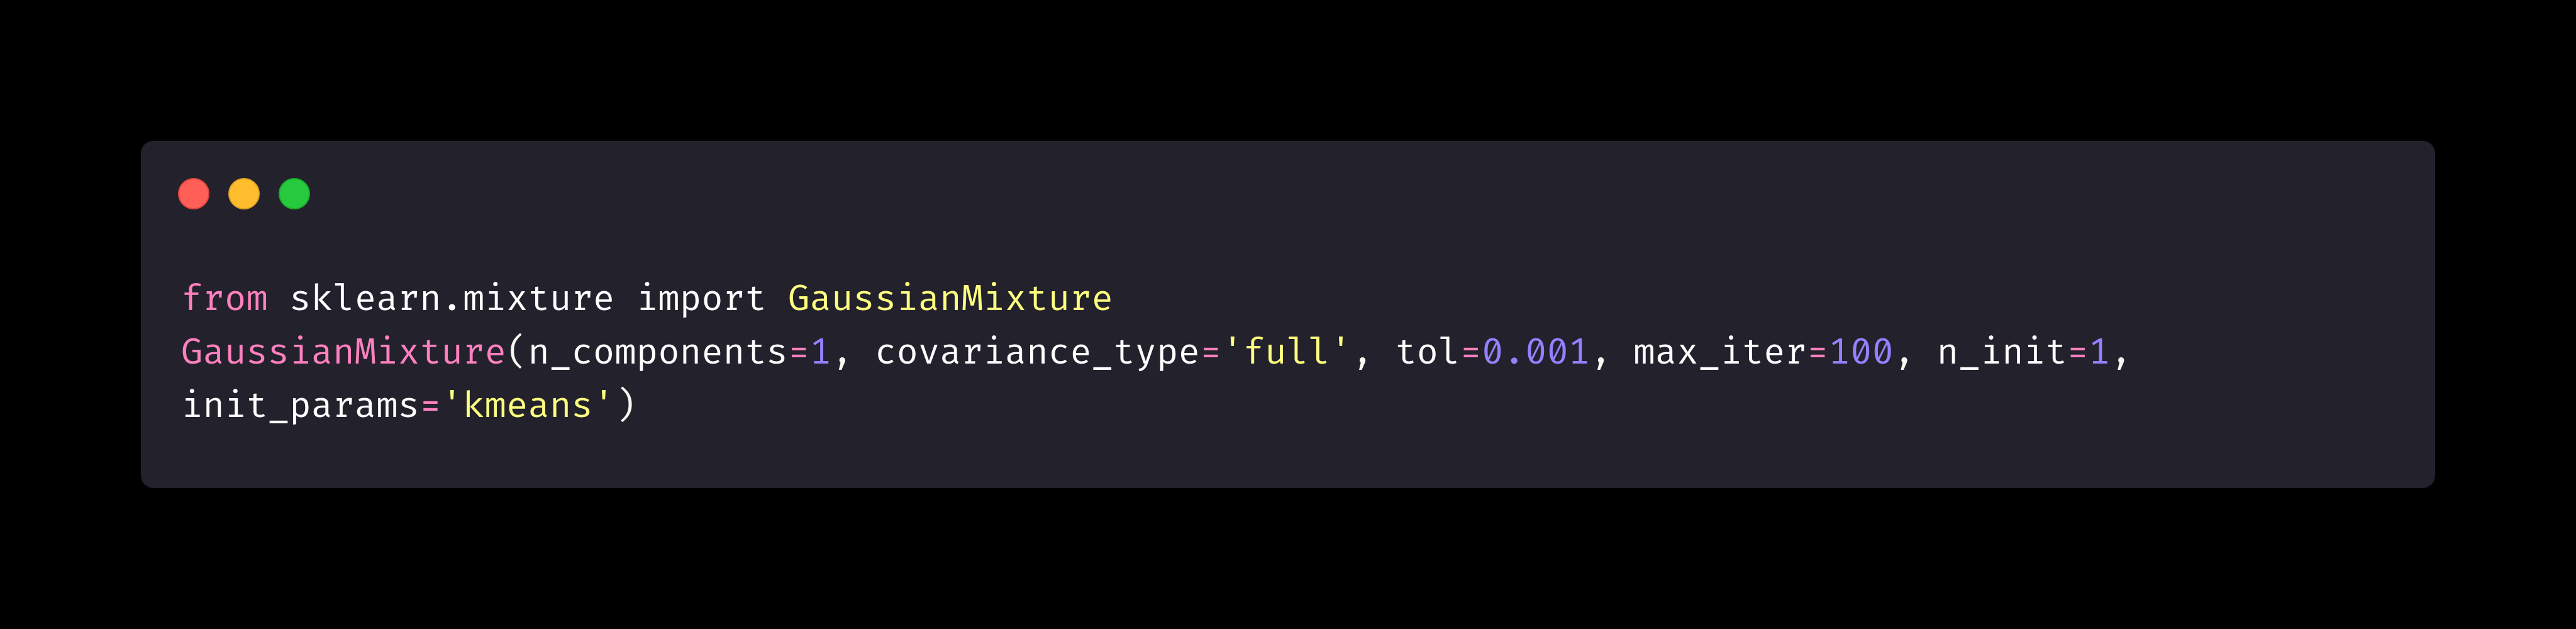

In [ ]:
from IPython.display import Image
Image('../figs/gmm_code.png')

Los parámetros de esta función, son los siguientes:

* `n_components:` Número de componentes/clusters a ajustar.
* `covariance_type:` Forma de la covarianza en los datos.
full: cada componente tiene su propia matriz de covarianza.
tied: todos los componente comparten la misma matriz de covarianza.
diag: cada componente tiene su propia matriz de covarianza diagonal.
spherical: cada componente tiene su propio valor de varianza.
* `tol:` límite de convergencia, si una iteración disminuye menos que este valor, el algoritmo finaliza.
* `max_iter:` número máximo de iteraciones.
* `n_init:` número de veces que se aplica el algoritmo (se queda con el mejor).
* `init_params:` forma de inicializar los parámetros (“kmeans”, “random”)

In [13]:
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot as plt
from sklearn import datasets
from plotnine import * 
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns 
import warnings 

# Omite Warnings 
warnings.simplefilter("ignore")

# Configuracion Entorno Plot
sns.set(rc={'figure.figsize':(5.27,5.27)})

In [14]:
iris = datasets.load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename'])

In [15]:
GMM = GaussianMixture(n_components=2, covariance_type="full")
GMM = GMM.fit(iris.data)

print("Porcentajes de datos \"modelado\" por cada componente",GMM.weights_,"\n")
print("Medias:\n",GMM.means_,"\n")
print("Matrices de covarianza:\n",GMM.covariances_,)

Porcentajes de datos "modelado" por cada componente [0.66667089 0.33332911] 

Medias:
 [[6.26198886 2.87199642 4.90597719 1.67599129]
 [5.00600639 3.4280142  1.46200203 0.24599932]] 

Matrices de covarianza:
 [[[0.43497387 0.12094155 0.44886533 0.16550229]
  [0.12094155 0.10961836 0.14138002 0.07923243]
  [0.44886533 0.14138002 0.67484296 0.2858736 ]
  [0.16550229 0.07923243 0.2858736  0.17863587]]

 [[0.12176331 0.09722605 0.01602717 0.01012447]
  [0.09722605 0.14080279 0.01146185 0.00911288]
  [0.01602717 0.01146185 0.02955704 0.00594818]
  [0.01012447 0.00911288 0.00594818 0.0108851 ]]]


In [16]:
# Asignando los datos a clusters
predicciones = GMM.predict_proba(iris.data)
print("Probabilidades de cada punto\n",predicciones[0:5,:])

Probabilidades de cada punto
 [[2.18043998e-11 1.00000000e+00]
 [7.81327712e-08 9.99999922e-01]
 [4.90263308e-09 9.99999995e-01]
 [1.32940646e-07 9.99999867e-01]
 [6.91148058e-12 1.00000000e+00]]


In [17]:
# Asignando cada punto a un cluster
clusters = np.argmax(predicciones, axis = 1)
print("Asignacion de clusters:\n", clusters)

Asignacion de clusters:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [18]:
# Visualizando en forma directa
tempData = pd.DataFrame(iris.data, columns = iris.feature_names)
tempData["labels"] = clusters
tempData2 = pd.DataFrame(GMM.means_, columns = iris.feature_names)
tempData2["labels"] = range(2)

In [19]:
tempData.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),labels
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [20]:
tempData2

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),labels
0,6.261989,2.871996,4.905977,1.675991,0
1,5.006006,3.428014,1.462002,0.245999,1


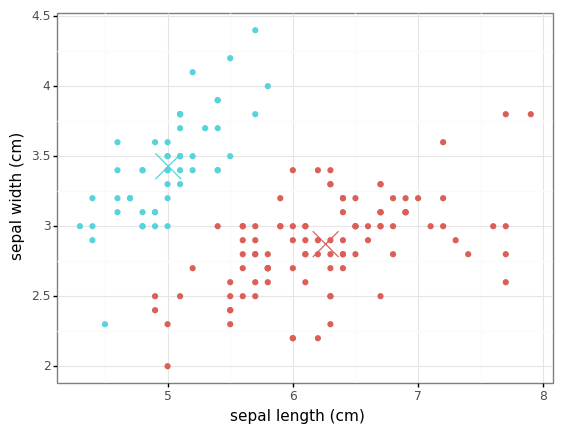

<ggplot: (8730849173065)>

In [21]:
(ggplot() 
 + aes(x = "sepal length (cm)", y = "sepal width (cm)", color = "factor(labels)")
 + theme_bw() 
 + geom_point(data=tempData,show_legend = False) 
 + geom_point(data=tempData2,show_legend = False, shape='x',size=10) 
)

In [22]:
numComponents = 2 
GMM = GaussianMixture(n_components = numComponents, covariance_type = 'spherical')
GMM.fit(iris.data)
predicciones = GMM.predict_proba(iris.data)
clusters = np.argmax(predicciones, axis=1)
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

* `full`: cada componente tiene su propia matriz de covarianza.
* `tied`: todos los componente comparten la misma matriz de covarianza.
* `diag`: cada componente tiene su propia matriz de covarianza diagonal.
* `spherical`: cada componente tiene su propio valor de varianza.

In [23]:
def make_ellipses(gmm, ax):
    #for n, color in enumerate(colors):
    for n in range(numComponents):
        if gmm.covariance_type == 'full':
            covariances = gmm.covariances_[n][:2, :2]
        elif gmm.covariance_type == 'tied':
            covariances = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == 'diag':
            covariances = np.diag(gmm.covariances_[n][:2])
        elif gmm.covariance_type == 'spherical':
            covariances = np.eye(gmm.means_.shape[1]) * gmm.covariances_[n]
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi  # convert to degrees
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        ell = mpl.patches.Ellipse(gmm.means_[n, :2], v[0], v[1],
                                  180 + angle, color=colors[n])
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.5)
        ax.add_artist(ell)

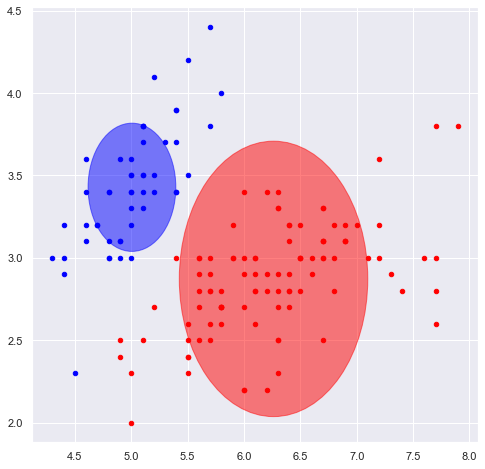

In [24]:
colors = ['red', 'blue', 'green','cyan']

plt.figure(figsize=(8, 8))
h = plt.subplot(1,1,1)
make_ellipses(GMM, h)
for i in range(numComponents):    
    data = iris.data[clusters == i]
    plt.scatter(data[:, 0], data[:, 1], s=20, color=colors[i])
plt.show()

In [25]:
numComponents = 3 
GMM = GaussianMixture(n_components=numComponents, covariance_type='diag')
GMM.fit(iris.data)
predicciones = GMM.predict_proba(iris.data)
clusters = np.argmax(predicciones, axis=1)

# Creando el dataframe para graficar (caso especial de colores)
tempData = pd.DataFrame(iris.data,columns=iris.feature_names)
tempData["labels"]=clusters
tempData.insert(5, "colorPoint","")
for i in range(tempData.shape[0]):
    output=(((predicciones[i,:])*255).astype("int"))
    tempData.iloc[i,5]='#%02x%02x%02x' % (output[0],output[1],output[2])

In [26]:
tempData.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),labels,colorPoint
0,5.1,3.5,1.4,0.2,2,#0000fe
1,4.9,3.0,1.4,0.2,2,#0000fe
2,4.7,3.2,1.3,0.2,2,#0000fe
3,4.6,3.1,1.5,0.2,2,#0000fe
4,5.0,3.6,1.4,0.2,2,#0000fe


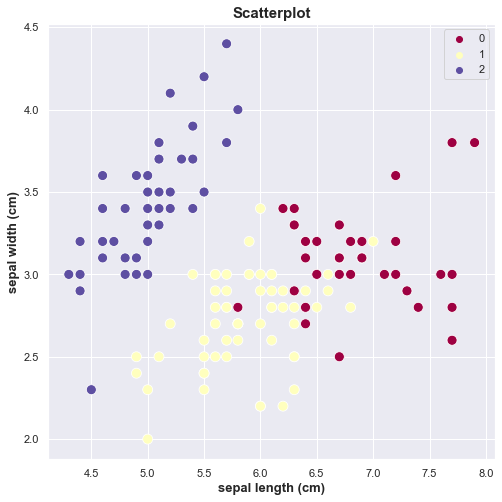

In [27]:
plt.figure(figsize=(8,8))
ax = sns.scatterplot(data = tempData, x="sepal length (cm)", y="sepal width (cm)", hue="labels", palette="Spectral", s=100)
ax.set_xlabel("sepal length (cm)", fontsize=13,fontweight='bold')
ax.set_ylabel("sepal width (cm)", fontsize=13,fontweight='bold')
ax.set_title("Scatterplot", fontsize=15,fontweight='bold')
ax.legend() 
plt.show()

#### **¿Cómo encuentro $k$?**

Criterio de información AIC y BIC : 

\begin{align*}
\hbox{AIC} &=& 2k -2\log{L} \\ 
\hbox{BIC} &=& k\log{N} -2\log{L} 
\end{align*}


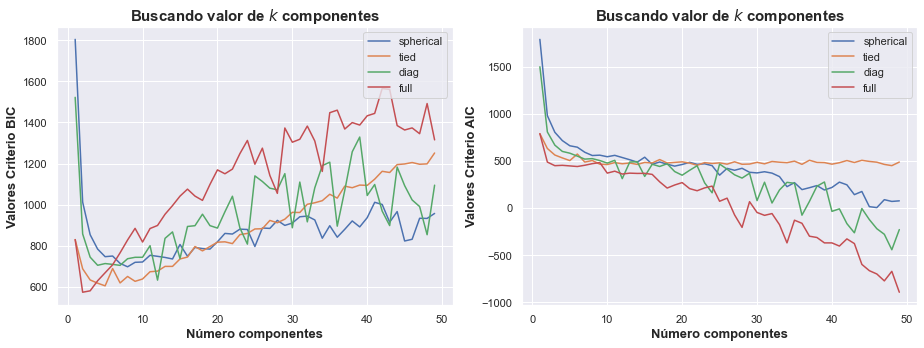

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))

maxNum = 50
n_components = range(1, maxNum)
covariance_types = ['spherical', 'tied', 'diag', 'full']

for covariance_type in covariance_types:
    valores_bic = []
    valores_aic = []
    for i in n_components:
        modelo = GaussianMixture(n_components = i, covariance_type = covariance_type)
        modelo = modelo.fit(iris.data)
        valores_bic.append(modelo.bic(iris.data))
        valores_aic.append(modelo.aic(iris.data))
    ax1.plot(n_components, valores_bic, label = covariance_type)
    ax2.plot(n_components, valores_aic, label = covariance_type)
    
# Plot asociados a los criterios bic 
ax1.set_title("Buscando valor de $k$ componentes", fontsize = 15, fontweight='bold')
ax1.set_xlabel("Número componentes", fontsize = 13, fontweight='bold')
ax1.set_ylabel("Valores Criterio BIC", fontsize = 13, fontweight='bold')
ax1.legend(loc=1)

# Plot asociados a los criterios aic 
ax2.set_title("Buscando valor de $k$ componentes", fontsize = 15, fontweight='bold')
ax2.set_xlabel("Número componentes", fontsize = 13, fontweight='bold')
ax2.set_ylabel("Valores Criterio AIC", fontsize = 13, fontweight='bold')
ax2.legend(loc=1)
plt.tight_layout()

En base al modelo entrenado, el número de $k$ es de 3 con matriz de covarianza `full`. (no olvidar la indexación en python)

In [29]:
modelo_gmm = GaussianMixture(n_components = 3, covariance_type = 'full', random_state = 123)
modelo_gmm.fit(X=iris.data)

GaussianMixture(n_components=3, random_state=123)